Cluster Selection Process:
This first notebook will allow us to determine the cluster selection from our data. New information suggests that the std_ values determine the acceleration of our cows. Since GPS are found in a collar, these values would represent vertical and horizontal movements, so it is enough to determine weather our cows are moving or not. We will try to use this data for our resting-sites cluster selection.


According to our article we have the following information:

    Exploratory analyses on data from static GPS devices were performed to establish
    QSSD thresholds. Positions with QSSD values less than 388 were classified as
    "Resting," values between 388 and 940 were designated as "No Class," and values
    greater than 940 were considered "Grazing." "No Class" positions were further refined
    by temporal correction; if flanked by positions of the same activity within a time gap of
    less than 15 minutes, the "No Class" position was reclassified to match the adjacent
    activity. For "Resting," an additional condition was applied: the distance to either the
    previous or subsequent position had to be less than 30 meters for reclassification as
    "Resting." This refinement reduced the number of "No Class" positions and improved activity classification.

and:

    To define a
    group of cows, we used 30 times the body length of a cow (ca. 60 m) as the maximum
    distance for cows to be considered part of the same group. 

These criteria should be enough to select our data properly, and to determine the clusters, which will be necessary for the data analysis. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

cows2021 = pd.read_csv('../Data/dades2021.csv')
cows2022 = pd.read_csv('../Data/dades2022.csv')
cows2023 = pd.read_csv('../Data/dades2023.csv')

cows2021["time"] = pd.to_datetime(cows2021['time'], format='ISO8601')
cows2022["time"] = pd.to_datetime(cows2022['time'], format='ISO8601')
cows2023["time"] = pd.to_datetime(cows2023['time'], format='ISO8601')

cows2021["id"] = cows2021["id"].astype(str) + "_2021"
cows2022["id"] = cows2022["id"].astype(str) + "_2022"
cows2023["id"] = cows2023["id"].astype(str) + "_2023"

cows = pd.concat([cows2021, cows2022, cows2023], ignore_index=True)
cows = cows.drop(columns=["diffhour", "diffdist", "velocity"])
cows['year'] = cows['time'].dt.year
summary = cows.groupby(['year', 'id']).size().reset_index(name='n_points')
print(summary.groupby('year')['n_points'].describe())

      count          mean          std     min       25%      50%       75%  \
year                                                                          
2021   80.0  10963.787500  2129.273613  6006.0  10408.75  11177.5  11544.75   
2022   80.0  10249.462500  3809.354399  3526.0   6656.50  11874.5  12579.75   
2023   85.0  10173.976471  3585.596679  1050.0   7289.00  11590.0  13057.00   

          max  
year           
2021  26001.0  
2022  25141.0  
2023  14276.0  


In [2]:
#so first things first, take cows that have calf info and filter through good data
from datetime import timedelta

calf = pd.read_csv('../Data/dades_calf.csv')
cows = cows[cows['id'].isin(calf['id_year'])]


#only take those GPS signals that seem reasonable.
per_cow_stats = cows.groupby(['year', 'id']).agg(
    n_points=('time', 'count'),
    n_days=('date', 'nunique')
).reset_index()

year_medians = per_cow_stats.groupby('year')[['n_points', 'n_days']].median().rename(columns={
    'n_points': 'median_points',
    'n_days': 'median_days'
})

merged = per_cow_stats.merge(year_medians, on='year')

merged['pct_points'] = (merged['n_points'] / merged['median_points']) * 100
merged['pct_days'] = (merged['n_days'] / merged['median_days']) * 100

# Keep only cows with >=**% of median for both metrics
final_ids = merged[
    (merged['pct_points'] >= 85) & 
    (merged['pct_days'] >= 85)
]['id']

cows = cows[cows['id'].isin(final_ids)].copy()
summary = cows.groupby(['year', 'id']).size().reset_index(name='n_points')
print(summary.groupby('year')['n_points'].describe())

      count          mean         std      min      25%      50%      75%  \
year                                                                        
2021   61.0  11184.672131  606.535482   9972.0  10792.0  11214.0  11656.0   
2022   44.0  12483.068182  544.118335  11590.0  11921.0  12494.5  12886.0   
2023   39.0  12943.256410  849.958009  11050.0  12349.5  12994.0  13540.0   

          max  
year           
2021  12375.0  
2022  13608.0  
2023  14276.0  


In [6]:
#determine activity
cows["STD_SQRT"] = np.sqrt(cows["std_x"]**2 + cows["std_y"]**2 + cows["std_z"]**2)

#according to our draft article we classify:
def classify_activity(value):
    if value < 388:
        return "Resting"
    elif value > 940:
        return "Grazing"
    else:
        return "No Class"

cows["activity"] = cows["STD_SQRT"].apply(classify_activity)
cows["activity"].value_counts()

activity
Resting     861872
Grazing     706938
No Class    167497
Name: count, dtype: int64

In [10]:
# 1. Ensure time column is datetime and sort
cows["time"] = pd.to_datetime(cows["time"])
cows = cows.sort_values(["id", "time"]).reset_index(drop=True)

# 2. Compute group-shifted columns
grouped = cows.groupby("id")
prev_act = grouped["activity"].shift(1)
next_act = grouped["activity"].shift(-1)
prev_time = grouped["time"].shift(1)
next_time = grouped["time"].shift(-1)

gap_prev = (cows["time"] - prev_time).dt.total_seconds() / 60
gap_next = (next_time - cows["time"]).dt.total_seconds() / 60

# 3. Define replacement condition
mask = (
    (cows["activity"] == "No Class") &
    (prev_act == next_act) &
    (prev_act != "No Class") &
    (gap_prev < 15) &
    (gap_next < 15)
)

# 4. Refine activities
cows.loc[mask, "activity"] = prev_act[mask]

# 5. Check activity value counts
print(cows["activity"].value_counts())

activity
Resting     896698
Grazing     721449
No Class    118160
Name: count, dtype: int64


In [13]:
#get elevation data:
import rasterio

# Open your DEM
dem = rasterio.open("../Data/catllar_dem.tif")

# 1. Read DEM raster band into memory
dem_array = dem.read(1)

# 2. Convert all (lng, lat) coordinates to pixel indices (cols, rows) at once
cols, rows = (~dem.transform) * (cows["lng"].values, cows["lat"].values)
rows = np.floor(rows).astype(int)
cols = np.floor(cols).astype(int)

# 3. Create a mask to handle coordinates outside the raster boundaries
height, width = dem_array.shape
valid_mask = (rows >= 0) & (rows < height) & (cols >= 0) & (cols < width)

# 4. Extract elevations using vector indexing
elevations = np.full(len(cows), np.nan)
elevations[valid_mask] = dem_array[rows[valid_mask], cols[valid_mask]]

# 5. Handle raster nodata values
if dem.nodata is not None:
    elevations[elevations == dem.nodata] = np.nan

cows["elevation"] = elevations
cows

,time,lng,lat,pos_x,pos_y,pos_z,std_x,std_y,std_z,max_x,max_y,max_z,temp,date,year,STD_SQRT,activity,id,elevation
0,2022-07-05 00:08:11,2.255039,42.368673,-1057.032,3171.097,-15855.484,0.000,0.000,0.000,126.379,22.341,126.379,26.687,2022-07-05,2022,0.000000,Resting,AJ701_2022,1874.0
1,2022-07-05 00:19:14,2.255055,42.368673,-1057.032,3171.097,-15855.484,0.000,90.988,90.988,126.379,348.260,348.260,26.687,2022-07-05,2022,128.676464,Resting,AJ701_2022,1874.0
2,2022-07-05 00:30:20,2.255024,42.368734,-3171.097,3171.097,-15855.484,216.407,90.988,216.407,714.907,714.907,714.907,27.306,2022-07-05,2022,319.284819,Resting,AJ701_2022,1874.0
3,2022-07-05 00:41:26,2.254932,42.368872,-3171.097,3171.097,-15855.484,0.000,0.000,0.000,126.379,22.341,126.379,27.306,2022-07-05,2022,0.000000,Resting,AJ701_2022,1880.0
4,2022-07-05 00:52:31,2.255283,42.368826,1057.032,-3171.097,-15855.484,0.000,0.000,0.000,126.379,126.379,126.379,23.594,2022-07-05,2022,0.000000,Resting,AJ701_2022,1871.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1736302,2023-10-26 22:37:22,2.263691,42.379583,-2048.000,-2048.000,16384.000,223.984,0.000,223.984,359.168,359.168,1140.288,27.306,2023-10-26,2023,316.761211,Resting,CJ375_2023,1979.0
1736303,2023-10-26 22:48:14,2.263676,42.379507,0.000,-2048.000,16384.000,0.000,0.000,223.984,359.168,359.168,359.168,27.306,2023-10-26,2023,223.984000,Resting,CJ375_2023,1967.0
1736304,2023-10-26 22:59:21,2.263676,42.379446,0.000,-4096.000,16384.000,0.000,0.000,223.984,359.168,359.168,359.168,26.068,2023-10-26,2023,223.984000,Resting,CJ375_2023,1967.0
1736305,2023-10-26 23:21:31,2.263432,42.379294,-4096.000,-2048.000,16384.000,0.000,0.000,223.984,359.168,359.168,359.168,26.687,2023-10-26,2023,223.984000,Resting,CJ375_2023,1953.0


In [16]:
# 1. Vectorized 3D distance function
def compute_3d_distance_vec(lat1, lon1, ele1, lat2, lon2, ele2):
    R = 6371000  # Earth radius in meters
    phi1, lam1, phi2, lam2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = phi2 - phi1
    dlon = lam2 - lam1
    
    a = np.sin(dlat / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlon / 2.0) ** 2
    surface_dist = 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    elev_diff = ele2 - ele1
    
    return np.sqrt(surface_dist**2 + elev_diff**2)

# 2. Sort by id and time
cows["time"] = pd.to_datetime(cows["time"])
cows = cows.sort_values(["id", "time"]).reset_index(drop=True)

# 3. Compute group shifts for preceding and succeeding coordinates
grouped = cows.groupby("id")
prev_lat = grouped["lat"].shift(1)
prev_lon = grouped["lng"].shift(1)
prev_ele = grouped["elevation"].shift(1)

next_lat = grouped["lat"].shift(-1)
next_lon = grouped["lng"].shift(-1)
next_ele = grouped["elevation"].shift(-1)

# 4. Calculate vectorized 3D distances
cows["dist_prev"] = compute_3d_distance_vec(
    cows["lat"], cows["lng"], cows["elevation"],
    prev_lat, prev_lon, prev_ele
)

dist_next = compute_3d_distance_vec(
    cows["lat"], cows["lng"], cows["elevation"],
    next_lat, next_lon, next_ele
)

# 5. Apply resting logic mask
mask = (cows["activity"] == "No Class") & ((cows["dist_prev"] < 30) | (dist_next < 30))
cows.loc[mask, "activity"] = "Resting"

# 6. Fill missing dist_prev values with median
cows["dist_prev"] = cows["dist_prev"].fillna(cows["dist_prev"].median())
cows

,time,lng,lat,pos_x,pos_y,pos_z,std_x,std_y,std_z,max_x,max_y,max_z,temp,date,year,STD_SQRT,activity,id,elevation,dist_prev
0,2022-07-05 00:08:11,2.255039,42.368673,-1057.032,3171.097,-15855.484,0.000,0.000,0.000,126.379,22.341,126.379,26.687,2022-07-05,2022,0.000000,Resting,AJ701_2022,1874.0,17.268258
1,2022-07-05 00:19:14,2.255055,42.368673,-1057.032,3171.097,-15855.484,0.000,90.988,90.988,126.379,348.260,348.260,26.687,2022-07-05,2022,128.676464,Resting,AJ701_2022,1874.0,1.253580
2,2022-07-05 00:30:20,2.255024,42.368734,-3171.097,3171.097,-15855.484,216.407,90.988,216.407,714.907,714.907,714.907,27.306,2022-07-05,2022,319.284819,Resting,AJ701_2022,1874.0,7.235176
3,2022-07-05 00:41:26,2.254932,42.368872,-3171.097,3171.097,-15855.484,0.000,0.000,0.000,126.379,22.341,126.379,27.306,2022-07-05,2022,0.000000,Resting,AJ701_2022,1880.0,18.048848
4,2022-07-05 00:52:31,2.255283,42.368826,1057.032,-3171.097,-15855.484,0.000,0.000,0.000,126.379,126.379,126.379,23.594,2022-07-05,2022,0.000000,Resting,AJ701_2022,1871.0,30.630194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1736302,2023-10-26 22:37:22,2.263691,42.379583,-2048.000,-2048.000,16384.000,223.984,0.000,223.984,359.168,359.168,1140.288,27.306,2023-10-26,2023,316.761211,Resting,CJ375_2023,1979.0,13.843151
1736303,2023-10-26 22:48:14,2.263676,42.379507,0.000,-2048.000,16384.000,0.000,0.000,223.984,359.168,359.168,359.168,27.306,2023-10-26,2023,223.984000,Resting,CJ375_2023,1967.0,14.749328
1736304,2023-10-26 22:59:21,2.263676,42.379446,0.000,-4096.000,16384.000,0.000,0.000,223.984,359.168,359.168,359.168,26.068,2023-10-26,2023,223.984000,Resting,CJ375_2023,1967.0,6.786894
1736305,2023-10-26 23:21:31,2.263432,42.379294,-4096.000,-2048.000,16384.000,0.000,0.000,223.984,359.168,359.168,359.168,26.687,2023-10-26,2023,223.984000,Resting,CJ375_2023,1953.0,29.766561


In [27]:
#cows.to_csv("../Data/dades_class.csv", index=False)

Cows csv saved, no need to repeat all the process above each time, just enough to go through with the data weel chosen and everything. This allows us to check the clustering algorithms in a much faster way.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import timedelta
import geopandas as gpd

cows = pd.read_csv('../Data/dades_class.csv')

In [22]:
from statsmodels.nonparametric.kernel_density import KDEMultivariate

#and now we select the resting activity.
resting = cows[cows["activity"] == "Resting"]
print(resting["activity"].value_counts())

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    resting,
    geometry=gpd.points_from_xy(resting["lng"], resting["lat"]),
    crs="EPSG:4326"
)

# Reproject to Web Mercator (meters)
#gdf = gdf.to_crs(epsg=3857)
gdf = gdf.to_crs(epsg=25831)
x = gdf.geometry.x.values
y = gdf.geometry.y.values

# Estimate bandwidths from the data
kde = KDEMultivariate(data=[x, y], var_type="cc")
bw_x, bw_y = kde.bw
print(f"Default bandwidths (meters): x = {bw_x:.2f}, y = {bw_y:.2f}")

target_radius = 30  # meters

# Compute adjustment factors
bw_adjust_x = target_radius / bw_x
bw_adjust_y = target_radius / bw_y

# Use the smaller one to ensure kernel is not too wide
bw_adjust = min(bw_adjust_x, bw_adjust_y)
print(f"Suggested bw_adjust for ~{target_radius}m kernel: {bw_adjust:.3f}")

activity
Resting    993110
Name: count, dtype: int64
Default bandwidths (meters): x = 83.07, y = 66.13
Suggested bw_adjust for ~30m kernel: 0.361


/Users/jan/Desktop/Uni/Biologia/Article/venv/lib/python3.14/site-packages/pandas/util/_decorators.py:220: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


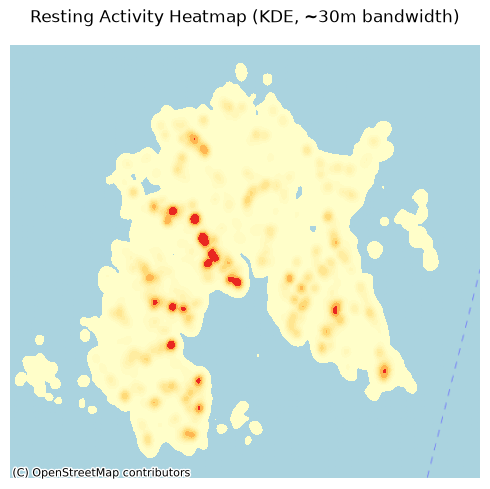

In [25]:
import seaborn as sns
import contextily as ctx

fig, ax = plt.subplots(figsize=(5, 5))

sns.kdeplot(
    x=x,
    y=y,
    fill=True,
    cmap="YlOrRd",
    bw_adjust=bw_adjust,
    thresh=0.003,  # or adjust based on how much noise you want to suppress, usually 0.03
    ax=ax
)

#need internet for this to work properly.
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, headers={"User-Agent": "MySpatialAnalysisApp/1.0"})
#ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f"Resting Activity Heatmap (KDE, ~{target_radius}m bandwidth)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../Plots/Article/baseheatmap_total.png")
plt.show()
plt.close()

In [26]:
#clustering methods:
from sklearn.preprocessing import StandardScaler
import hdbscan


gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y
gdf["z"] = gdf["elevation"]

# Create 3D array: X, Y, Z
coords_3d = gdf[["x", "y", "z"]].values

# Scale all three dimensions equally
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords_3d)
avg_std = scaler.scale_.mean()  # average std across x, y, z
epsilon_normalized = float(30 / avg_std)
print(f"For a 30m difference: effective epsilon ≈ {epsilon_normalized:.5f} in standard")

For a 30m difference: effective epsilon ≈ 0.05767 in standard


/Users/jan/Desktop/Biologia/Article/venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jan/Desktop/Biologia/Article/venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Outliers: 7.618%


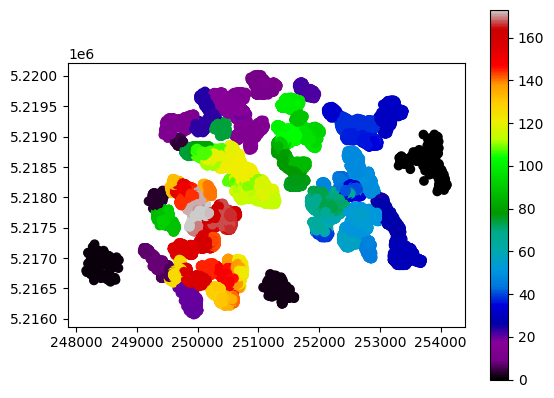

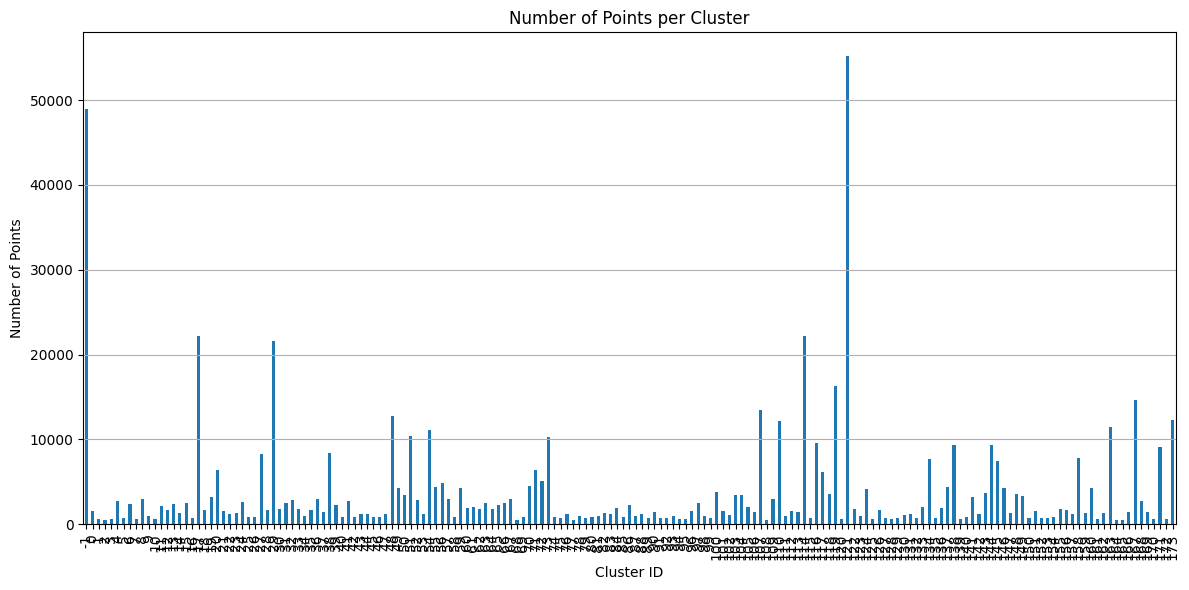

In [37]:
"""
Run HDBSCAN, with min_cluster_size to be chosen, min_samples to be understood and
cluster_selection_epsilon as above. If multiplied by 4, then distances have to be around 
120m to be considered the same

Parameters for cluster choosing:
-> min_cluster_size: the smallest amount of points in a cluster so it is considered as one. Maybe choose
                     in reference to the amount of positions per night we have (median) and then estimate.
                     
-> min_samples: how conservative we want the Excess of Mass algorithm to work, meaning that a higher value
                ranging in (1, min_cluster_size) will determine how strict our clustering routine is. The 
                smaller the value, more clusters, the larger, less clusters.
                
-> cluster_selection_epsilon: calculated from above determines if two positions are considered close-by or
                              not. To know how many meters it refers to, just make avg_std*epsilon,
                              when set to 4*epsilon_normalized it is roughly 120m.

We are aiming at something around a 5-15% of outliers, the smaller the better. Different criteria will
have different results. In order to pass the data, we want a clustering method: "regional" clusters, 
another one seen as "decent amount of clusters", and a complete "small cluster units" that reflects
the heatmap shown before. These 3 points should suffice for the moment.
"""

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,        # How many are the minimal points in a cluster
    min_samples=50,             # How strict HDBSCAN is in terms of positions, 1 would be a lot of small clusters, the higher, the contrary
    cluster_selection_epsilon = epsilon_normalized,
    metric='euclidean'
)
labels = clusterer.fit_predict(coords_scaled)

# Add to your GeoDataFrame
gdf["cluster_id"] = labels

noise_ratio = (labels == -1).sum()/len(labels)
print(f"Outliers: {noise_ratio:.3%}")

gdf[gdf["cluster_id"] != -1].plot(column="cluster_id", cmap="nipy_spectral", legend=True)

cluster_counts = gdf["cluster_id"].value_counts().sort_index()
# Bar plot
plt.figure(figsize=(12, 6))
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Points")
plt.title("Number of Points per Cluster")
plt.xticks(rotation=90)  # Rotate x-labels if many clusters
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [22]:
#This part choses a cluster based on the most repeated cluster during a night.
gdf = gdf.sort_values(by=['id', 'night_date', 'time'])
gdf['delta_time'] = gdf.groupby(['id', 'night_date'])['time'].diff().dt.total_seconds()/3600

# Fill NaNs (first record per group) with 0 or small constant (e.g., 30 seconds)
gdf['delta_time'] = gdf['delta_time'].fillna(0)

cluster_time = gdf.groupby(['id', 'night_date', 'cluster_id'])['delta_time'].sum().reset_index()
# For each id and night, get cluster with max total time
main_cluster = cluster_time.sort_values(['id', 'night_date', 'delta_time'], ascending=[True, True, False])
main_cluster = main_cluster.drop_duplicates(subset=['id', 'night_date'], keep='first')

main_cluster = main_cluster.rename(columns={'cluster_id': 'main_cluster'})

# Merge
if 'main_cluster' in gdf.columns:
    gdf = gdf.drop(columns=['main_cluster'])
    
gdf = gdf.merge(
    main_cluster[['id', 'night_date', 'main_cluster']],
    on=['id', 'night_date'],
    how='left'
)

# Keep only rows in the main cluster per cow and night
main_cluster_points = gdf[gdf['cluster_id'] == gdf['main_cluster']]
medians = main_cluster_points.groupby(['id', 'night_date'])[['lat', 'lng', 'elevation']].median().reset_index()

main_cluster = main_cluster.merge(medians, on=['id', 'night_date'], how='left')
main_cluster


,id,night_date,main_cluster,delta_time,lat,lng,elevation
0,AJ701_2022,2022-07-04,-1,7.760556,42.368795,2.255070,1874.0
1,AJ701_2022,2022-07-05,30,10.548889,42.371771,2.248325,2095.0
2,AJ701_2022,2022-07-06,42,9.431667,42.377386,2.248081,2091.0
3,AJ701_2022,2022-07-07,42,8.506667,42.379431,2.244907,2261.0
4,AJ701_2022,2022-07-08,-1,6.630556,42.371710,2.242817,2263.0
...,...,...,...,...,...,...,...
15196,CJ375_2023,2023-10-22,38,8.887778,42.379095,2.262730,1933.0
15197,CJ375_2023,2023-10-23,38,10.897778,42.378439,2.264851,1969.0
15198,CJ375_2023,2023-10-24,34,9.437778,42.377813,2.269886,1950.0
15199,CJ375_2023,2023-10-25,38,8.150278,42.378798,2.263081,1929.0


In [23]:
#This part choses a cluster based on the least movement of an hour during the night
from sklearn.preprocessing import MinMaxScaler

gdf['hour'] = gdf['time'].dt.hour
agg = gdf.groupby(['id', 'night_date', 'hour'])[['STD_SQRT', "dist_prev"]].median().reset_index()
agg = agg.loc[:, ~agg.columns.duplicated()]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(agg[['STD_SQRT', 'dist_prev']])
scaled_df = pd.DataFrame(scaled, columns=['STD_SQRT_scaled', 'dist_prev_scaled'])

# Reset index to align properly
scaled_df.index = agg.index

# Concatenate
agg = pd.concat([agg, scaled_df], axis=1)

# Combine
agg['combined'] = np.sqrt(agg['STD_SQRT_scaled']**2 + agg['dist_prev_scaled']**2)

# Step 3: Select the hour with least movement
least_movement = agg.sort_values(['id', 'night_date', 'combined']).drop_duplicates(['id', 'night_date'])

gdf = gdf.merge(
    least_movement[['id', 'night_date', 'hour']],
    on=['id', 'night_date'],
    how='left',
    suffixes=('', '_least')
)

least_hour_points = gdf[gdf['hour'] == gdf['hour_least']].copy()
main_cluster_alt = (
    least_hour_points.groupby(['id', 'night_date', 'cluster_id'])
    .size()
    .reset_index(name='count')
    .sort_values(['id', 'night_date', 'count'], ascending=[True, True, False])
    .drop_duplicates(['id', 'night_date'])  # select the dominant cluster
    .rename(columns={'cluster_id': 'main_cluster'})
)

joined = least_hour_points.merge(
    main_cluster_alt[['id', 'night_date', 'main_cluster']],
    left_on=['id', 'night_date', 'cluster_id'],
    right_on=['id', 'night_date', 'main_cluster'],
    how='inner'
)

medians = (
    joined.groupby(['id', 'night_date', 'hour'])[['lat', 'lng', 'elevation']]
    .median()
    .reset_index()
)

# Final output: cluster + position
main_cluster_alt = main_cluster_alt.merge(
    medians, on=['id', 'night_date'], how='left'
)
main_cluster_alt

,id,night_date,main_cluster,count,hour,lat,lng,elevation
0,AJ701_2022,2022-07-04,-1,5,0,42.368734,2.255039,1874.0
1,AJ701_2022,2022-07-05,30,5,5,42.371542,2.248524,2084.0
2,AJ701_2022,2022-07-06,42,5,22,42.377401,2.248066,2091.0
3,AJ701_2022,2022-07-07,42,6,2,42.379416,2.244961,2261.0
4,AJ701_2022,2022-07-08,24,6,3,42.371725,2.243290,2247.0
...,...,...,...,...,...,...,...,...
15196,CJ375_2023,2023-10-22,38,4,22,42.379034,2.262844,1930.5
15197,CJ375_2023,2023-10-23,38,4,21,42.379644,2.263317,1969.0
15198,CJ375_2023,2023-10-24,34,1,6,42.377813,2.269703,1946.0
15199,CJ375_2023,2023-10-25,38,2,2,42.378851,2.262715,1918.0


In [24]:
#compare methods:
# From time-based method
main_cluster_time = main_cluster[['id', 'night_date', 'main_cluster']].copy()

# From least-movement hour method
main_cluster_least = main_cluster_alt[['id', 'night_date', 'main_cluster']].copy()
main_cluster_least = main_cluster_least.rename(columns={'main_cluster': 'main_cluster_least'})

comparison = main_cluster_time.merge(
    main_cluster_least,
    on=['id', 'night_date'],
    how='inner'  # or 'outer' if some combinations are missing in one
)

comparison['match'] = comparison['main_cluster'] == comparison['main_cluster_least']
n_total = len(comparison)
n_match = comparison['match'].sum()
n_diff = n_total - n_match

print(f"Total nights compared: {n_total}")
print(f"Same cluster selected by both methods: {n_match} ({n_match / n_total:.1%})")
print(f"Different cluster selected: {n_diff} ({n_diff / n_total:.1%})")

mismatches = comparison[~comparison['match']]
print(mismatches.head())


Total nights compared: 15201
Same cluster selected by both methods: 14488 (95.3%)
Different cluster selected: 713 (4.7%)
            id  night_date  main_cluster  main_cluster_least  match
4   AJ701_2022  2022-07-08            -1                  24  False
36  AJ701_2022  2022-08-09            -1                   3  False
38  AJ701_2022  2022-08-11            -1                  31  False
55  AJ701_2022  2022-08-28            42                  -1  False
60  AJ701_2022  2022-09-02            42                  -1  False


In [25]:
# Step 1: Prepare both DataFrames
main_cluster = main_cluster.rename(columns={
    'main_cluster': 'cluster_time',
    'lat': 'lat_time',
    'lng': 'lng_time',
    'elevation': 'elevation_time'
})

main_cluster_alt = main_cluster_alt.rename(columns={
    'main_cluster': 'cluster_least',
    'lat': 'lat_least',
    'lng': 'lng_least',
    'elevation': 'elevation_least'
})

In [26]:
threshold_hours = 6  # define your threshold
main_cluster['use_main'] = main_cluster['delta_time'] >= threshold_hours
n_total = len(main_cluster)
n_main = main_cluster['use_main'].sum()
n_least = n_total - n_main

print(f"Total nights: {n_total}")
print(f"→ Using main_cluster: {n_main} ({n_main / n_total:.3%})")
print(f"→ Using least-movement cluster: {n_least} ({n_least / n_total:.3%})")


# Step 2: Merge both decisions
final = main_cluster.merge(
    main_cluster_alt,
    on=['id', 'night_date'],
    how='outer'
)

# Step 3: Apply selection logic
def choose(row, col_time, col_least):
    return row[col_time] if row['use_main'] else row[col_least]

final['final_cluster'] = final.apply(lambda r: choose(r, 'cluster_time', 'cluster_least'), axis=1)
final['lat'] = final.apply(lambda r: choose(r, 'lat_time', 'lat_least'), axis=1)
final['lng'] = final.apply(lambda r: choose(r, 'lng_time', 'lng_least'), axis=1)
final['elevation'] = final.apply(lambda r: choose(r, 'elevation_time', 'elevation_least'), axis=1)
final=final.drop(columns=["cluster_time", "lat_time", "lng_time", "elevation_time", "use_main", "cluster_least", "count", "lat_least", "lng_least", "elevation_least"])
final=final.rename(columns={'delta_time':'hours_cluster', 'hour':'least_hour'})

noise_ratio = len(final[final["final_cluster"]==-1])/len(final)
print(f"percentage of outliers: {noise_ratio:.3%}")

final



Total nights: 15201
→ Using main_cluster: 14443 (95.013%)
→ Using least-movement cluster: 758 (4.987%)
percentage of outliers: 4.743%


,id,night_date,hours_cluster,least_hour,final_cluster,lat,lng,elevation
0,AJ701_2022,2022-07-04,7.760556,0,-1,42.368795,2.255070,1874.0
1,AJ701_2022,2022-07-05,10.548889,5,30,42.371771,2.248325,2095.0
2,AJ701_2022,2022-07-06,9.431667,22,42,42.377386,2.248081,2091.0
3,AJ701_2022,2022-07-07,8.506667,2,42,42.379431,2.244907,2261.0
4,AJ701_2022,2022-07-08,6.630556,3,-1,42.371710,2.242817,2263.0
...,...,...,...,...,...,...,...,...
15196,CJ375_2023,2023-10-22,8.887778,22,38,42.379095,2.262730,1933.0
15197,CJ375_2023,2023-10-23,10.897778,21,38,42.378439,2.264851,1969.0
15198,CJ375_2023,2023-10-24,9.437778,6,34,42.377813,2.269886,1950.0
15199,CJ375_2023,2023-10-25,8.150278,2,38,42.378798,2.263081,1929.0


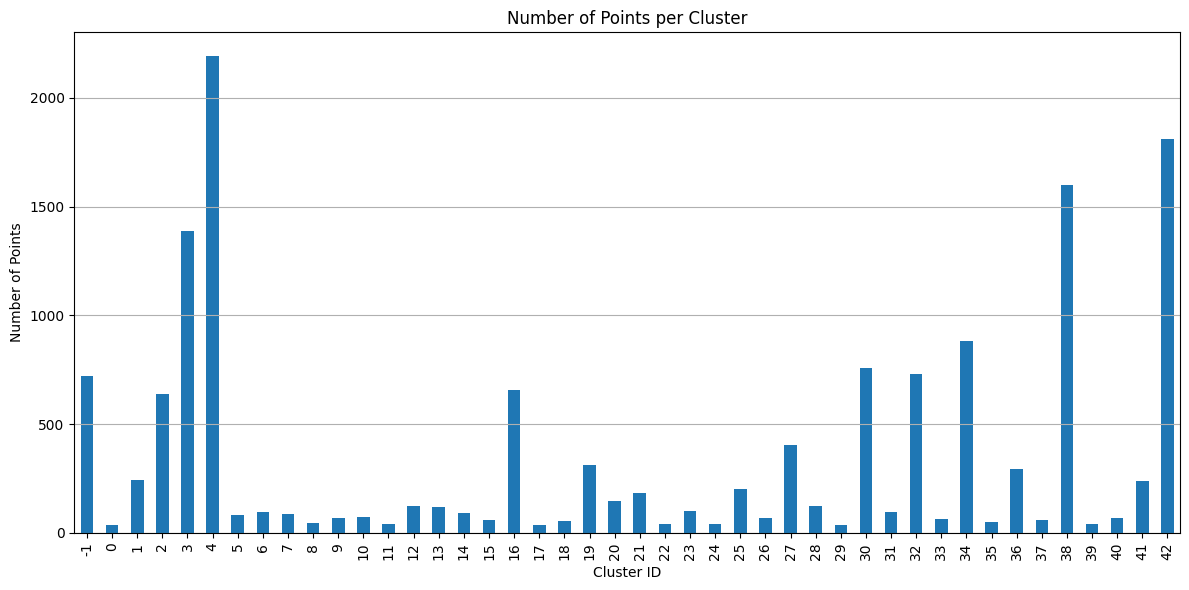

In [30]:
#Count points per cluster (excluding noise points with cluster_id == -1)
#cluster_counts = gdf[gdf["cluster_id"] != -1]["cluster_id"].value_counts().sort_index()

cluster_counts = final["final_cluster"].value_counts().sort_index()

# Bar plot
plt.figure(figsize=(12, 6))
cluster_counts.plot(kind="bar")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Points")
plt.title("Number of Points per Cluster")
plt.xticks(rotation=90)  # Rotate x-labels if many clusters
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [ ]:
#we can save some data here, depending on which clustering algorithm works finest for us. 
#A small explanation on parameters should work better as well.
final.to_csv("../Data/dades_cluster.csv", index=False)